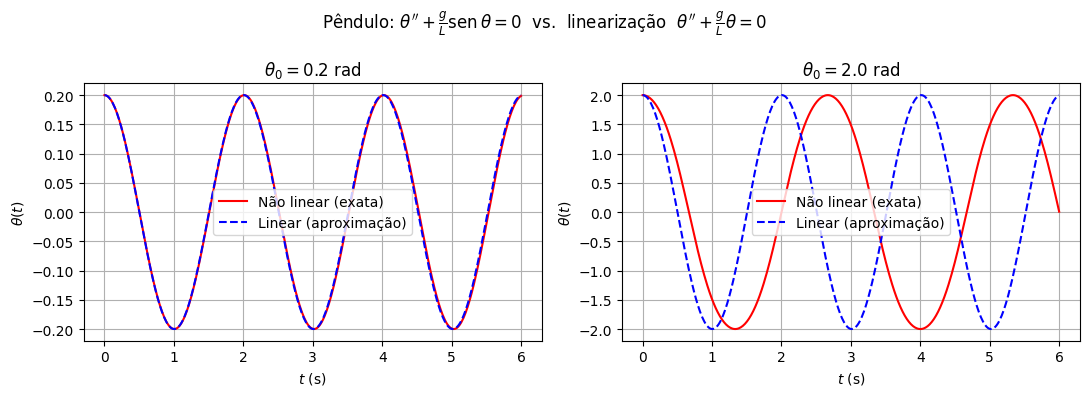

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

g, L = 9.8, 1.0

def pendulo_nao_linear(y, t):
    theta, omega = y
    return [omega, -(g/L)*np.sin(theta)]

def pendulo_linear(y, t):
    theta, omega = y
    return [omega, -(g/L)*theta]

t = np.linspace(0, 6, 400)

fig, axs = plt.subplots(1, 2, figsize=(11, 4))

for theta0, ax in zip([0.2, 2.0], axs):
    sol_nl = odeint(pendulo_nao_linear, [theta0, 0], t)
    sol_l  = odeint(pendulo_linear, [theta0, 0], t)
    ax.plot(t, sol_nl[:, 0], 'r', label="Não linear (exata)")
    ax.plot(t, sol_l[:, 0], 'b--', label="Linear (aproximação)")
    ax.set_title(fr"$\theta_0={theta0}$ rad")
    ax.set_xlabel("$t$ (s)"); ax.set_ylabel(r"$\theta(t)$")
    ax.legend(); ax.grid(True)

plt.suptitle(r"Pêndulo: $\theta''+\frac{g}{L}\text{sen}\,\theta=0$  vs.  linearização  $\theta''+\frac{g}{L}\theta=0$")
plt.tight_layout()
plt.show()

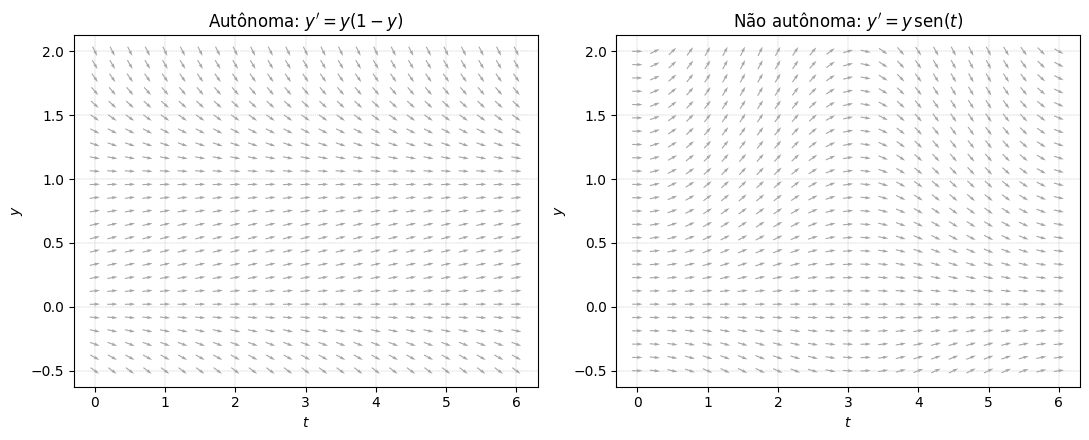

In [2]:
def f_autonoma(y, t):
    return y*(1 - y)

def f_nao_autonoma(y, t):
    return y*np.sin(t)

t_grid = np.linspace(0, 6, 25)
y_grid = np.linspace(-0.5, 2, 25)
T, Y = np.meshgrid(t_grid, y_grid)

fig, axs = plt.subplots(1, 2, figsize=(11, 4.5))

for f, titulo, ax in [(f_autonoma, r"Autônoma: $y'=y(1-y)$", axs[0]),
                       (f_nao_autonoma, r"Não autônoma: $y'=y\,\text{sen}(t)$", axs[1])]:
    dT = np.ones(T.shape)
    dY = f(Y, T)
    Lnorm = np.sqrt(dT**2 + dY**2)
    ax.quiver(T, Y, dT/Lnorm, dY/Lnorm, color='gray', alpha=0.7, pivot='mid')
    ax.set_title(titulo)
    ax.set_xlabel("$t$"); ax.set_ylabel("$y$")
    ax.grid(True, linestyle='--', linewidth=0.3)

plt.tight_layout()
plt.show()